In [1]:
import pandas as pd
import seaborn as sns
import path_config
sns.set_theme() 

In [5]:
from lib.utils_plotting import print_avg_results, results_file, get_mae

results, results_w_regions = results_file("test", selected_months=[3,6,9,12])
results_val, results_w_regions_val = results_file("val", selected_months=[3,6,9,12])

# Ensemble key — precomputed by run_jobs/ensemble_shallow_multiscale48.sh
# Run that script first to generate the CSV, then re-run this notebook.
simple_key = "ensemble_multiscale_crop48_shallow_transformer_test"

results_mae = {"HLStile": [], "Date": [], "MAE": [], "Method": [], "SiteID": [], "years": []}
for tile, siteid, year in results_w_regions["shallow_transformer_pixels_1.0_test"][["HLStile", "SiteID", "years"]].drop_duplicates().values:
    for key in results_w_regions.keys():
        results_mae = get_mae(results_w_regions[key], tile, siteid, year, results_mae, key)

results_mae_df = pd.DataFrame(results_mae)

## A- Overview of methods' results

1- The Shallow Temporal only Transformer from prior work performs the best. 

2- The Shallow Temporal model trained on our data performs better than prior work data. 

3- Pretraining improves the performance of Prithvi. 

In [6]:
methods_to_print = ["random_baseline_1.0_test",
                    "shallow_transformer_pixels_1.0_test", 
                    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                               G     M     S     D  Mean
Method                                                                                  
random_baseline_1.0_test                                    38.5  35.6  37.7  37.5  37.3
shallow_transformer_pixels_1.0_test                         14.5  13.6  19.2  17.7  16.2
prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test  13.6  12.7  18.8  17.4  15.6
shallow_transformer_pixels_priorwork_data_test              13.4  10.7  16.6  15.4  14.0


## B- Effect of crop size on multiscale model performance

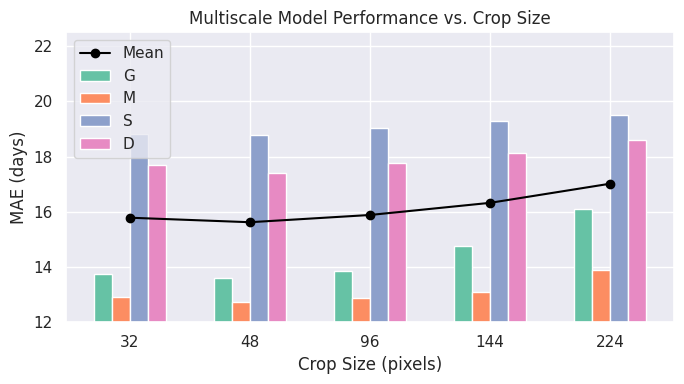

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Map crop sizes to their result keys
crop_methods = {
    32:  "prithvi_pretrained_multiscale_crops_conv3d_crop32_1.0_test",
    48:  "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
    96:  "prithvi_pretrained_multiscale_crops_conv3d_crop96_1.0_test",
    144: "prithvi_pretrained_multiscale_crops_conv3d_crop144_1.0_test",
    224: "prithvi_pretrained_multiscale_crops_conv3d_crop224_1.0_test",
}

dates = ["G", "M", "S", "D"]
crop_sizes = sorted(crop_methods.keys())

# Compute mean MAE per date and overall for each crop size
mae_per_date = {d: [] for d in dates}
mae_mean = []

for cs in crop_sizes:
    key = crop_methods[cs]
    df_crop = results_mae_df[results_mae_df["Method"] == key]
    for d in dates:
        mae_per_date[d].append(df_crop[df_crop["Date"] == d]["MAE"].mean())
    mae_mean.append(df_crop["MAE"].mean())

# Plot
fig, ax = plt.subplots(figsize=(7, 4))

x = np.arange(len(crop_sizes))
width = 0.15
colors = sns.color_palette("Set2", 5)

for i, d in enumerate(dates):
    ax.bar(x + i * width, mae_per_date[d], width, label=d, color=colors[i])

# Mean line
ax.plot(x + 1.5 * width, mae_mean, marker='o', color='black', linewidth=1.5, label='Mean', zorder=5)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels([str(cs) for cs in crop_sizes])
ax.set_xlabel("Crop Size (pixels)")
ax.set_ylabel("MAE (days)")
ax.set_title("Multiscale Model Performance vs. Crop Size")
ax.legend()
ax.set_ylim(12, 22.5)
plt.tight_layout()
plt.show()

## B2 - Progressive Multi-Scale Ensemble

Starting from the crop32 model alone, we progressively add larger crop sizes into a convex ensemble and plot the resulting MAE.

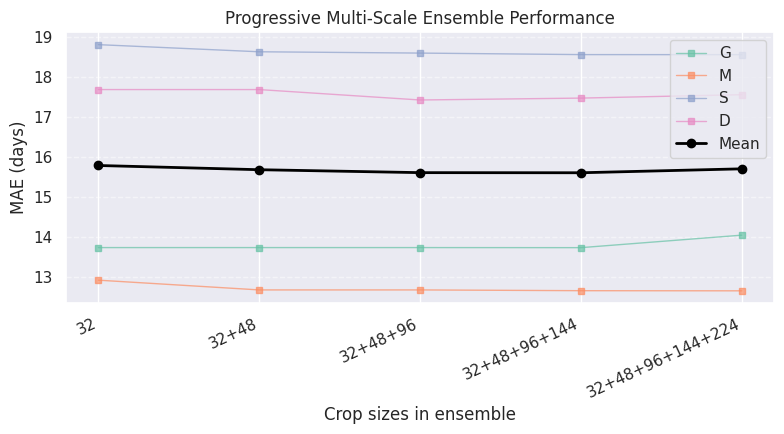


Crops                           G       M       S       D    Mean
------------------------------------------------------------
32                           13.7    12.9    18.8    17.7    15.8
32+48                        13.7    12.7    18.6    17.7    15.7
32+48+96                     13.7    12.7    18.6    17.4    15.6
32+48+96+144                 13.7    12.7    18.6    17.5    15.6
32+48+96+144+224             14.0    12.6    18.6    17.6    15.7


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Progressive ensemble keys (each step adds the next crop size)
progressive_steps = [
    ("32",               "prithvi_pretrained_multiscale_crops_conv3d_crop32_1.0_test"),
    ("32+48",            "ensemble_multiscale_crop32_crop48_test"),
    ("32+48+96",         "ensemble_multiscale_crop32_crop48_crop96_test"),
    ("32+48+96+144",     "ensemble_multiscale_crop32_crop48_crop96_crop144_test"),
    ("32+48+96+144+224", "ensemble_multiscale_crop32_crop48_crop96_crop144_crop224_test"),
]

dates = ["G", "M", "S", "D"]

# Compute MAE for each progressive step
step_labels = []
step_mae_per_date = {d: [] for d in dates}
step_mae_mean = []

for label, key in progressive_steps:
    df_step = results_mae_df[results_mae_df["Method"] == key]
    step_labels.append(label)
    per_date = []
    for d in dates:
        mae = df_step[df_step["Date"] == d]["MAE"].mean()
        step_mae_per_date[d].append(mae)
        per_date.append(mae)
    step_mae_mean.append(np.mean(per_date))

# Plot
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(step_labels))
colors = sns.color_palette("Set2", 5)

for i, d in enumerate(dates):
    ax.plot(x, step_mae_per_date[d], marker='s', markersize=5, label=d,
            color=colors[i], linewidth=1, alpha=0.7)

ax.plot(x, step_mae_mean, marker='o', color='black', linewidth=2, label='Mean', zorder=5)

ax.set_xticks(x)
ax.set_xticklabels(step_labels, rotation=25, ha='right')
ax.set_xlabel("Crop sizes in ensemble")
ax.set_ylabel("MAE (days)")
ax.set_title("Progressive Multi-Scale Ensemble Performance")
ax.legend(loc="upper right")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print table
print(f"\n{'Crops':<25s}  {'G':>6s}  {'M':>6s}  {'S':>6s}  {'D':>6s}  {'Mean':>6s}")
print("-" * 60)
for i, label in enumerate(step_labels):
    vals = [step_mae_per_date[d][i] for d in dates]
    print(f"{label:<25s}  {vals[0]:6.1f}  {vals[1]:6.1f}  {vals[2]:6.1f}  {vals[3]:6.1f}  {step_mae_mean[i]:6.1f}")

## C- Does Prithvi have any advantges? 

We split performance per eco region. We note that: 

1- Prithvi performs substantially better on the North American Deserts region. 

2- This improvements disappears when the pretraining is absent highlighting its significance. 

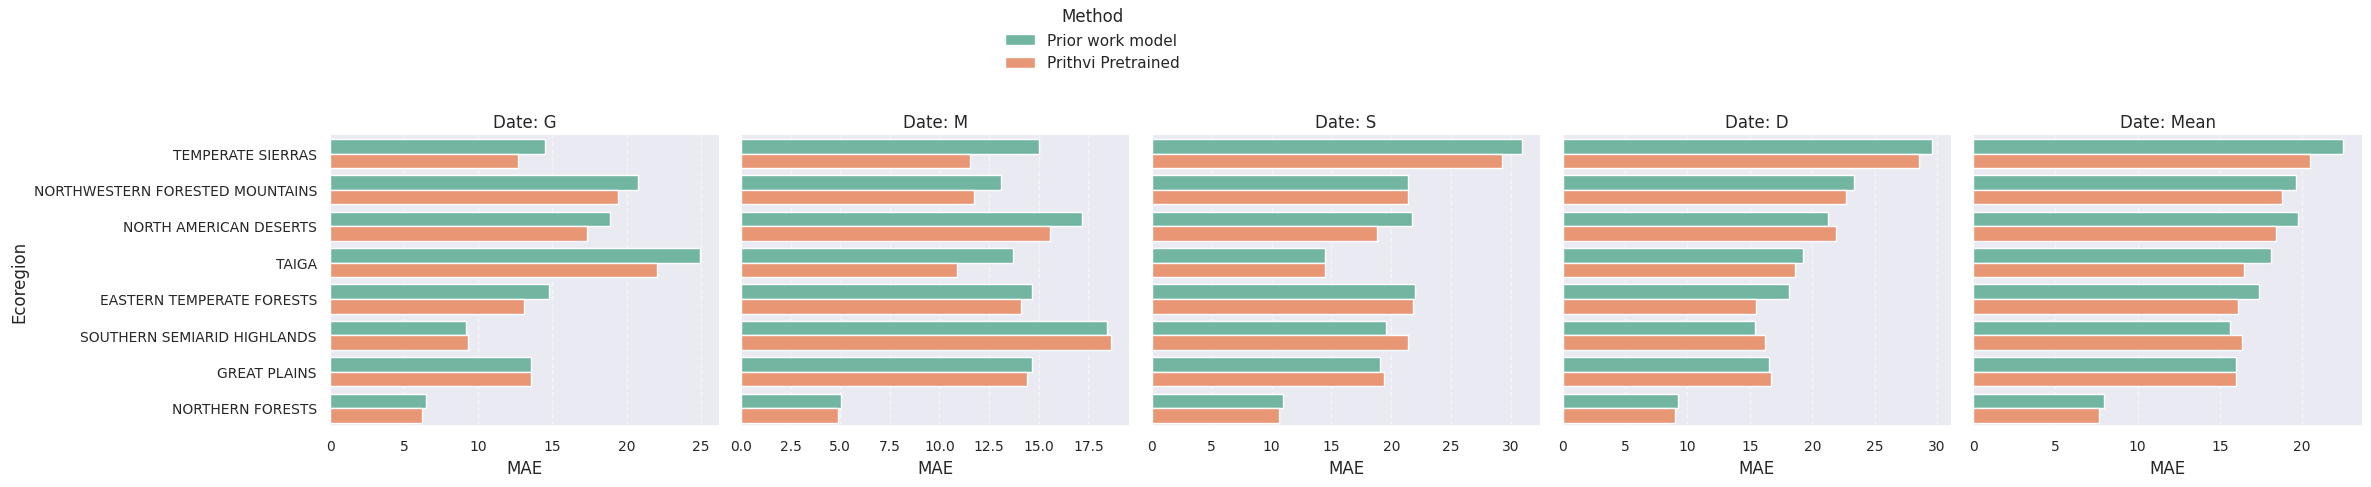

In [9]:
from lib.utils_plotting import plot_methods_regions_split

results_mae_df_ = results_mae_df.copy()
results_mae_df_["Method"] = results_mae_df_["Method"].replace("shallow_transformer_pixels_1.0_test", "Prior work model")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test", "Prithvi Pretrained")

plot_methods_regions_split(results_mae_df_, 
                            geo_path=path_config.get_data_geojson(),
                            eco_path="useco1/NA_CEC_Eco_Level1.shp",
                            methods=["Prior work model", "Prithvi Pretrained"],
                         )

### D- Can we make use of this improved performance? 

We propose to use an Ensemble model that combines prior work shallow transformer and Prithvi outputs. Observe below that ensemble model significantly improves average performance, especially on north american deserts region. 

In [10]:
methods_to_print = ["shallow_transformer_pixels_1.0_test",
                    "prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test",
                    simple_key,
                    "shallow_transformer_pixels_priorwork_data_test"]
avg_results = print_avg_results(methods_to_print, results_mae_df)

                                                               G     M     S     D  Mean
Method                                                                                  
shallow_transformer_pixels_1.0_test                         14.5  13.6  19.2  17.7  16.2
prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test  13.6  12.7  18.8  17.4  15.6
ensemble_multiscale_crop48_shallow_transformer_test         13.5  12.5  18.5  17.0  15.4
shallow_transformer_pixels_priorwork_data_test              13.4  10.7  16.6  15.4  14.0


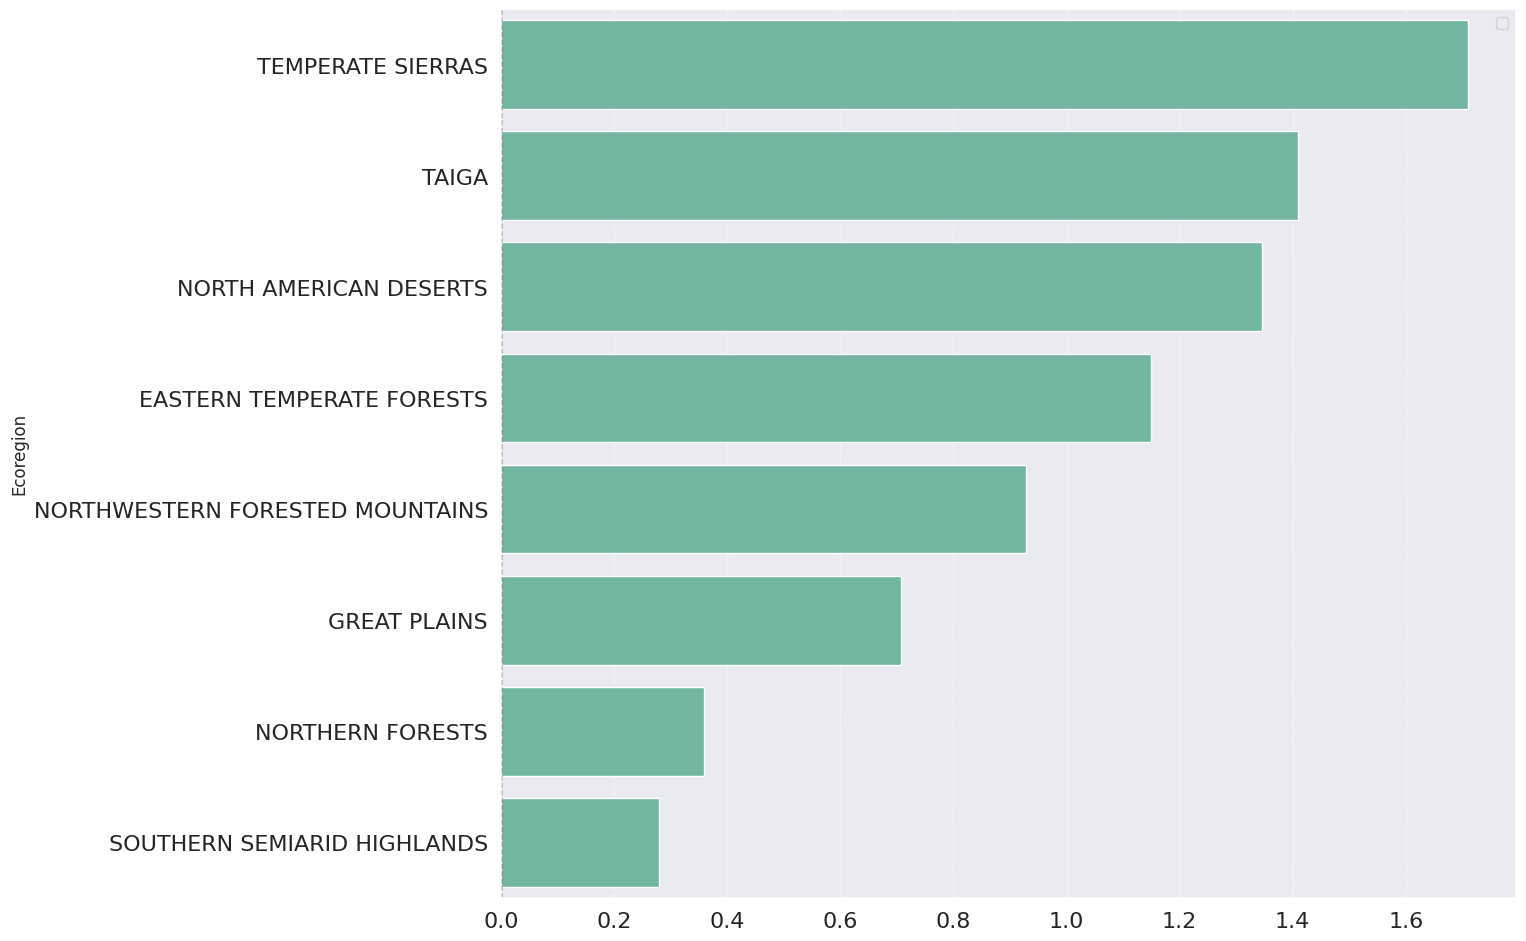

In [11]:
from lib.utils_plotting import plot_mae_improvement_by_region

results_mae_df_ = results_mae_df.copy()
plot_mae_improvement_by_region(
    results_mae_df_,
    geo_path=path_config.get_data_geojson(),
    eco_path="useco1/NA_CEC_Eco_Level1.shp",
    methods_to_compare=[simple_key],
    anchor_method="shallow_transformer_pixels_1.0_test",
    figsize=(14, 10)
)

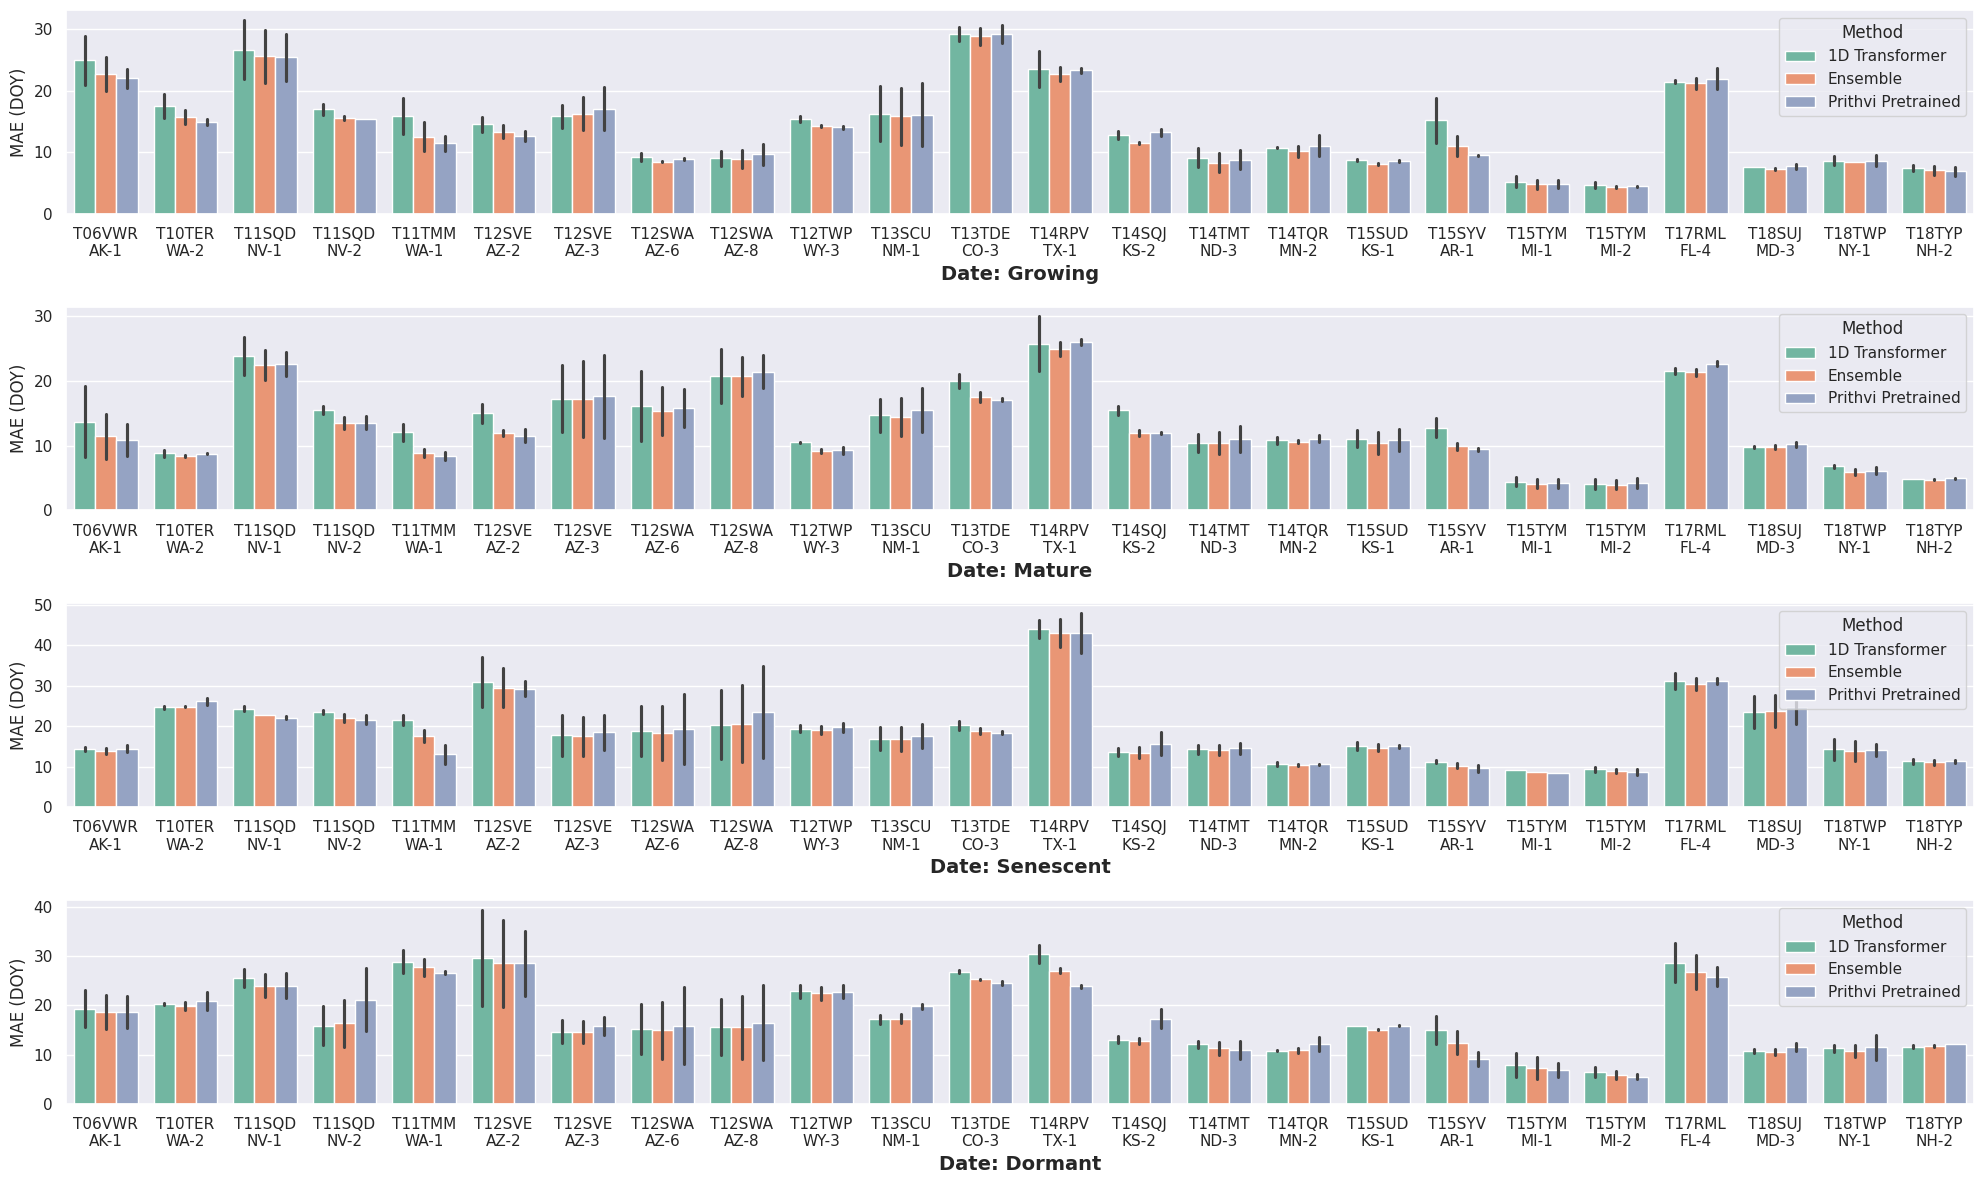

In [12]:
from lib.utils_plotting import plot_performance_tiles
results_mae_df_ = results_mae_df.copy()
results_mae_df_["Method"] = results_mae_df_["Method"].replace("shallow_transformer_pixels_1.0_test", "1D Transformer")
results_mae_df_["Method"] = results_mae_df_["Method"].replace("prithvi_pretrained_multiscale_crops_conv3d_crop48_1.0_test", "Prithvi Pretrained")
results_mae_df_["Method"] = results_mae_df_["Method"].replace(simple_key, "Ensemble")

plot_performance_tiles(results_mae_df_, methods=["1D Transformer",
                                                  "Prithvi Pretrained",
                                                  "Ensemble"])